## 1. Imports

We add the project root to `sys.path` so we can import `dataset` and `embedder`
(VAE, SelfAttention2D, LPIPS, PatchGANDiscriminator, VAECombinedLoss).

The losses module provides:
- **LPIPS** — perceptual loss via VGG16 feature maps (preserves fine details)
- **PatchGANDiscriminator** — 70×70 PatchGAN that classifies local patches as real/fake
- **VAECombinedLoss** — wraps MSE + KL(β) + LPIPS + adversarial into a single call

In [2]:
import sys
sys.path.insert(0, "..")

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt
from torchinfo import summary

from dataset import RecordingDataset
from embedder import VAE, PatchGANDiscriminator, VAECombinedLoss, discriminator_loss
from tqdm import tqdm

## 2. Гиперпараметры

Устройство, batch size, эпохи, learning rates, размер и параметры латента.

**Модель — квадратный латент `(B, 4, 32, 32)` = 4096 (сжатие 48:1, doom_sq_mid_49):**
- `LATENT_DIM = 4` — каналы латента (не flat-вектор)
- `ENCODER_CHANNELS = [64, 128, 256]` — 3 ступени даунсэмплинга (256² → 32²)
- `ATTENTION_LAYERS = [2]` — внимание на 2-й ступени (32×32)

**Loss weights:**
- `BETA = 0.1` — сниженное KL-давление, чтобы латент нёс больше информации
- `LPIPS_WEIGHT = 0.1` — перцептивное расстояние помогает сохранять NPC / монстров
- `ADV_WEIGHT = 0.01` — adversarial loss делает текстуры чётче

Два отдельных оптимизатора: для VAE (генератора) и для дискриминатора.

In [16]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = 8
EPOCHS = 50
LR_VAE = 3e-5
LR_D = 3e-5

# doom_sq_mid_49: square latent (B, 4, 32, 32), 48:1 compression
IMG_SIZE = 96
LATENT_DIM = 2
FLAT_LATENT = False
ENCODER_CHANNELS = [32, 64, 64, 128]
USE_RESBLOCKS = True
USE_ATTENTION = False
ATTENTION_LAYERS = [2]
NUM_ATTENTION_HEADS = 4
RES_BLOCKS_PER_STAGE = 1
NORM_GROUPS = 32

BETA = 0.1
LPIPS_WEIGHT = 0.1
ADV_WEIGHT = 0.01

## 3. Датасет

`RecordingDataset` в `mode='vae'` ищет сессии doom в `../try/` (и подпапке `Doom/`)
и возвращает отдельные кадры как тензоры `(C, H, W)`.

⚠️ VAE обучен на 256×256, а новые записи doom — 192×192. Кадры ресайзятся
до `IMG_SIZE` через `ResizedVAEDataset`.

In [4]:
class ResizedVAEDataset(torch.utils.data.Dataset):
    """Resize VAE frames to (size, size) — new doom recordings are 192x192."""
    def __init__(self, dataset, size):
        super().__init__()
        self.dataset = dataset
        self.size = size

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        x = self.dataset[idx]
        if x.shape[-1] != self.size:
            x = F.interpolate(
                x.unsqueeze(0), size=(self.size, self.size),
                mode="bilinear", align_corners=False,
            ).squeeze(0)
        return x


dataset = RecordingDataset(data_dir="../try/CarRacing/", game="car", mode="vae")
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

## 4. Модели

**VAE** — 3-ступенчатый ResNet-энкодер (resblocks + GroupNorm), каналы 64→128→256.
Каждая ступень: ``ResBlock2D`` ×1 → ``DownsampleBlock(k=4,s=2)``.
Attention (SelfAttention2D) на 2-й ступени (32×32).
Латент — квадрат `(4, 32, 32)` = 4096 (48:1 сжатие).
Декодер: ``Upsample(nearest,×2) + Conv2d(k=3)`` — без шахматных артефактов.

**Дискриминатор** — 70×70 PatchGAN (4 conv-слоя + InstanceNorm + LeakyReLU).
Классифицирует каждый локальный патч независимо, заставляя VAE генерировать
резкие локальные текстуры.

In [17]:
vae = VAE(
    in_channels=3,
    latent_dim=LATENT_DIM,
    img_size=IMG_SIZE,
    flat_latent=FLAT_LATENT,
    encoder_channels=ENCODER_CHANNELS,
    use_resblocks=USE_RESBLOCKS,
    use_attention=USE_ATTENTION,
    attention_layers=ATTENTION_LAYERS,
    num_attention_heads=NUM_ATTENTION_HEADS,
    res_blocks_per_stage=RES_BLOCKS_PER_STAGE,
    norm_groups=NORM_GROUPS,
    final_activation="sigmoid",
).to(DEVICE)

summary(vae, input_size=(1, 3, IMG_SIZE, IMG_SIZE))

discriminator = PatchGANDiscriminator(in_channels=3, ndf=64).to(DEVICE)

In [8]:
x = next(iter(dataloader))

In [18]:
out, x1, x2 = vae(x)

In [19]:
x1.shape

torch.Size([8, 2, 12, 12])

## 5. Loss & Optimisers

`VAECombinedLoss` computes MSE + β·KL + LPIPS + adversarial in one forward pass.

We use AdamW for both the VAE and the discriminator. Separate optimisers are
needed because the discriminator trains on real vs. fake patches, while the VAE
tries to fool it.

In [ ]:
criterion = VAECombinedLoss(
    lpips_weight=LPIPS_WEIGHT,
    adv_weight=ADV_WEIGHT,
    beta=BETA,
).to(DEVICE)

opt_vae = optim.AdamW(vae.parameters(), lr=LR_VAE)
opt_d = optim.AdamW(discriminator.parameters(), lr=LR_D)

## 6. Training loop

Each iteration:
1. **Discriminator step** — real images → D(real)=1, reconstructions → D(fake)=0
2. **VAE step** — MSE + β·KL + LPIPS + fool discriminator

The discriminator gradients are detached from the VAE decoder's output
so they don't flow into the encoder during the D step.

Every epoch ends with a validation grid saved to `weights/doom/val_epoch_NNN.png`
and a model checkpoint via `save_pretrained`.

In [ ]:
for epoch in range(EPOCHS):
    vae.train()
    discriminator.train()
    total_loss = 0.0
    last_batch = None

    pbar = tqdm(dataloader, desc=f"Epoch {epoch+1}/{EPOCHS}")
    for batch in pbar:
        x = batch.to(DEVICE)

        # ---------- VAE forward ----------
        recon_x, mu, logvar = vae(x)

        # ---------- Discriminator step ----------
        d_real = discriminator(x)
        d_fake = discriminator(recon_x.detach())
        loss_d, _ = discriminator_loss(d_real, d_fake, loss_type="lsgan")

        opt_d.zero_grad()
        loss_d.backward()
        opt_d.step()

        # ---------- VAE (generator) step ----------
        d_fake_for_vae = discriminator(recon_x)

        losses = criterion(recon_x, x, mu, logvar, d_fake_for_vae)

        opt_vae.zero_grad()
        losses["loss"].backward()
        opt_vae.step()

        total_loss += losses["loss"].item()
        last_batch = x

        pbar.set_postfix(
            loss=f"{losses['loss'].item():.2e}",
            mse=f"{losses['mse'].item():.2e}",
            lpips=f"{losses['lpips'].item():.2e}",
            adv=f"{losses['adv'].item():.2e}",
        )

    avg_loss = total_loss / len(dataloader.dataset)
    print(f"Epoch {epoch+1}/{EPOCHS}, Avg loss: {avg_loss:.4f}")

    vae.eval()
    with torch.no_grad():
        recon_vae = vae(last_batch)[0]
        n = min(4, len(last_batch))
        orig = last_batch[:n].cpu()
        recon_imgs = recon_vae[:n].cpu()

        fig, axes = plt.subplots(2, n, figsize=(3 * n, 6))
        for i in range(n):
            axes[0, i].imshow(np.transpose(orig[i].numpy(), (1, 2, 0)))
            axes[0, i].axis("off")
            axes[1, i].imshow(np.transpose(recon_imgs[i].numpy(), (1, 2, 0)))
            axes[1, i].axis("off")
        axes[0, 0].set_ylabel("Original")
        axes[1, 0].set_ylabel("Reconstruction")
        plt.suptitle(f"Epoch {epoch+1}/{EPOCHS}")
        plt.tight_layout()
        plt.savefig(f"../weights/doom/val_epoch_{epoch+1:03d}.png", dpi=150)
        plt.close()

    vae.save_pretrained(f"../weights/doom_{epoch}")
    print(f"Checkpoint saved to ../weights/doom_{epoch}")
    vae.train()

## 7. PCA latent analysis

Проверяем структуру латентного пространства.
20% датасета → encode (mu, logvar → z) → flatten 4096D → PCA → 2D.

Если структура есть — кадры лягут по сценам (траектории-ленты, а не облако шума).
Это диагностика перед обучением предиктора.

In [ ]:
# Последний сохранённый чекпоинт (по логам обучения)
CKPT = "../weights/doom_vae_sd"
# CKPT = "../weights/doom_sq_mid"  # если сохранялся без суффикса эпохи
vae = VAE.from_pretrained(CKPT, map_location=DEVICE)
vae.eval()
print(f"VAE: latent_dim={vae.latent_dim}, flat_latent={vae.flat_latent}, "
      f"resblocks={vae.use_resblocks}, attn={vae.use_attention}")

VAE: latent_dim=4, flat_latent=False, resblocks=True, attn=True


### 7.1 Сбор латентов (20% датасета)

Случайная подвыборка → encode → reparameterize → flatten.
Индексы кадров сохраняем для раскраски по времени.

In [16]:
class ResizedVAEDataset(torch.utils.data.Dataset):
    """Resize VAE frames to (size, size) — new doom recordings are 192x192."""
    def __init__(self, dataset, size):
        super().__init__()
        self.dataset = dataset
        self.size = size

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        x = self.dataset[idx]
        if x.shape[-1] != self.size:
            x = F.interpolate(
                x.unsqueeze(0), size=(self.size, self.size),
                mode="bilinear", align_corners=False,
            ).squeeze(0)
        return x


dataset = ResizedVAEDataset(
    RecordingDataset(data_dir="../try", game="doom", mode="vae"), size=IMG_SIZE
)
print(f"Full dataset: {len(dataset):,} frames")

n_sample = max(1, int(len(dataset) * 0.4))
rng = torch.Generator().manual_seed(42)
indices = torch.randperm(len(dataset), generator=rng)[:n_sample]
subset = torch.utils.data.Subset(dataset, indices.tolist())
loader = DataLoader(subset, batch_size=32, shuffle=False)

Z_list = []
with torch.no_grad():
    for x in tqdm(loader):
        x = x.to(DEVICE)
        mu, logvar = vae.encode(x)
        z = vae.reparameterize(mu, logvar)
        Z_list.append(z.view(z.size(0), -1).cpu())

Z = torch.cat(Z_list, dim=0).numpy()
frame_orig_idx = indices.numpy()  # позиции в исходном датасете (game time)
print(f"Latent matrix: {Z.shape} (frames × dims)")

Full dataset: 3,124 frames


100%|██████████| 40/40 [04:20<00:00,  6.51s/it]

Latent matrix: (1249, 4096) (frames × dims)


### 7.2 PCA — оценка внутренней размерности

Сколько компонент реально информативны? Если для 90% нужно >50 — латент «рыхлый».
Если PC1+PC2 > 30% — 2D проекция осмысленна.

Components for 90% variance: 51
Components for 95% variance: 51
PC1: 2.2%  PC2: 1.3%


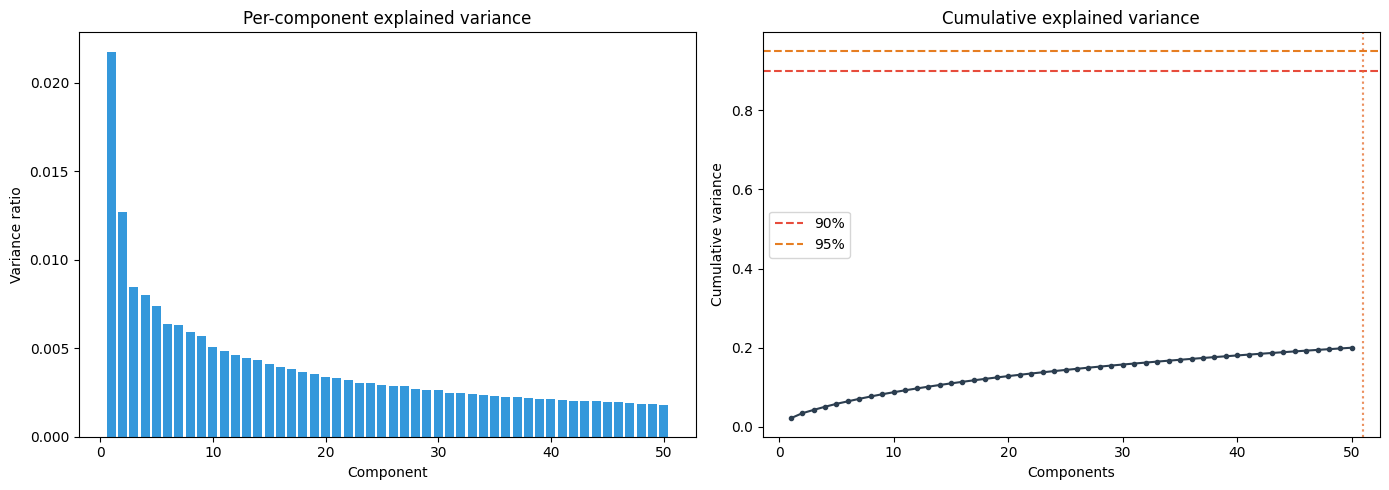

In [18]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

Z_scaled = StandardScaler().fit_transform(Z)

pca50 = PCA(n_components=50)
pca50.fit(Z_scaled)
cumsum = np.cumsum(pca50.explained_variance_ratio_)

n90 = np.searchsorted(cumsum, 0.9) + 1
n95 = np.searchsorted(cumsum, 0.95) + 1
print(f"Components for 90% variance: {n90}")
print(f"Components for 95% variance: {n95}")
print(f"PC1: {pca50.explained_variance_ratio_[0]*100:.1f}%  PC2: {pca50.explained_variance_ratio_[1]*100:.1f}%")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(range(1, 51), pca50.explained_variance_ratio_[:50], width=0.8, color="#3498db")
axes[0].set_xlabel("Component")
axes[0].set_ylabel("Variance ratio")
axes[0].set_title("Per-component explained variance")

axes[1].plot(range(1, 51), cumsum, "o-", markersize=3, color="#2c3e50")
axes[1].axhline(0.9, color="#e74c3c", linestyle="--", label="90%")
axes[1].axhline(0.95, color="#e67e22", linestyle="--", label="95%")
axes[1].axvline(n90, color="#e74c3c", linestyle=":", alpha=0.5)
axes[1].axvline(n95, color="#e67e22", linestyle=":", alpha=0.5)
axes[1].set_xlabel("Components")
axes[1].set_ylabel("Cumulative variance")
axes[1].legend()
axes[1].set_title("Cumulative explained variance")
plt.tight_layout()
plt.show()

### 7.3 Общая карта латентного пространства

Каждая точка — кадр. **Цвет = game time** → видим траектории.
Поверх точек — **миниатюры кадров** (до 800, при большем N — прореживание).
Близкие миниатюры = похожие сцены в латенте, ленты = связность во времени.
Если миниатюры разбросаны хаотично — латент «рыхлый» (см. 7.2 и 7.4).
Настройки: `MAX_THUMBS` (число миниатюр) и `ZOOM` (размер).

PC1+PC2 total variance: 3.4%


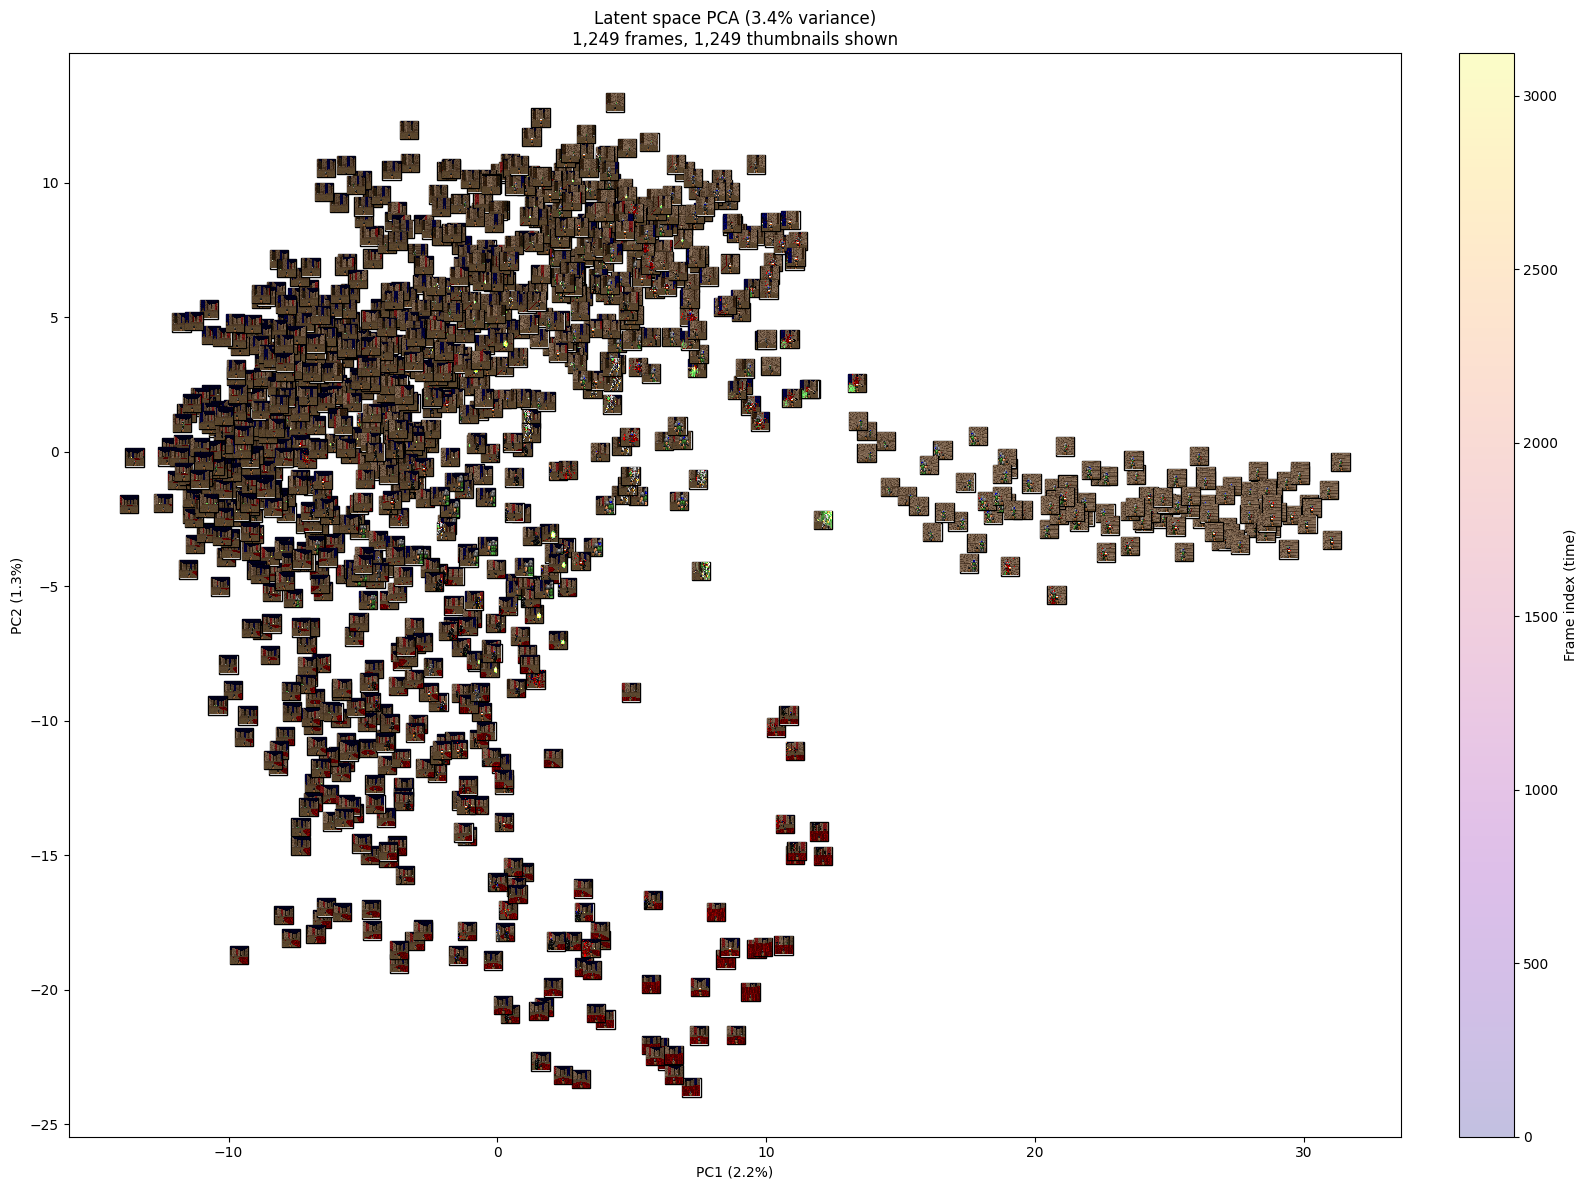

In [28]:
from matplotlib.offsetbox import OffsetImage, AnnotationBbox

pca2 = PCA(n_components=2)
Z_2d = pca2.fit_transform(Z_scaled)
pc_sum = pca2.explained_variance_ratio_.sum() * 100
print(f"PC1+PC2 total variance: {pc_sum:.1f}%")

fig, ax = plt.subplots(figsize=(16, 12))

# Фон: все точки мелкими маркерами
ax.scatter(
    Z_2d[:, 0], Z_2d[:, 1],
    c=frame_orig_idx, cmap="plasma", s=3, alpha=0.25, edgecolors="none", zorder=1
)

# Миниатюры кадров на каждой точке (прореживание при большом N)
MAX_THUMBS = 800
ZOOM = 0.05          # 256px * 0.05 ≈ 13px миниатюра
step = max(1, len(Z_2d) // MAX_THUMBS)
shown = 0
for i in range(0, len(Z_2d), step):
    orig_idx = int(frame_orig_idx[i])
    img = dataset[orig_idx].permute(1, 2, 0).numpy()  # (H, W, 3) в [0,1]
    im = OffsetImage(img, zoom=ZOOM, interpolation="nearest")
    ab = AnnotationBbox(im, (Z_2d[i, 0], Z_2d[i, 1]), frameon=True, pad=0.02, zorder=2)
    ax.add_artist(ab)
    shown += 1

cbar = plt.colorbar(ax.collections[0], ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Frame index (time)")
ax.set_xlabel(f"PC1 ({pca2.explained_variance_ratio_[0]*100:.1f}%)")
ax.set_ylabel(f"PC2 ({pca2.explained_variance_ratio_[1]*100:.1f}%)")
ax.set_title(f"Latent space PCA ({pc_sum:.1f}% variance)\n"
          f"{len(Z):,} frames, {shown:,} thumbnails shown")
plt.tight_layout()
plt.show()

### 7.4 Дисперсия по димам

Сколько димов «живые» (несут сигнал), а сколько «мёртвые» (шум)?
Если >80% димов имеют дисперсию <1% от максимальной — латент избыточен,
предиктору достаточно сжатия до 256–512 димов.

Dims total: 4096, max var: 1.5985
Живые димы (>1% от max): 4096 (100.0%)
Мёртвые димы (<1% от max): 0


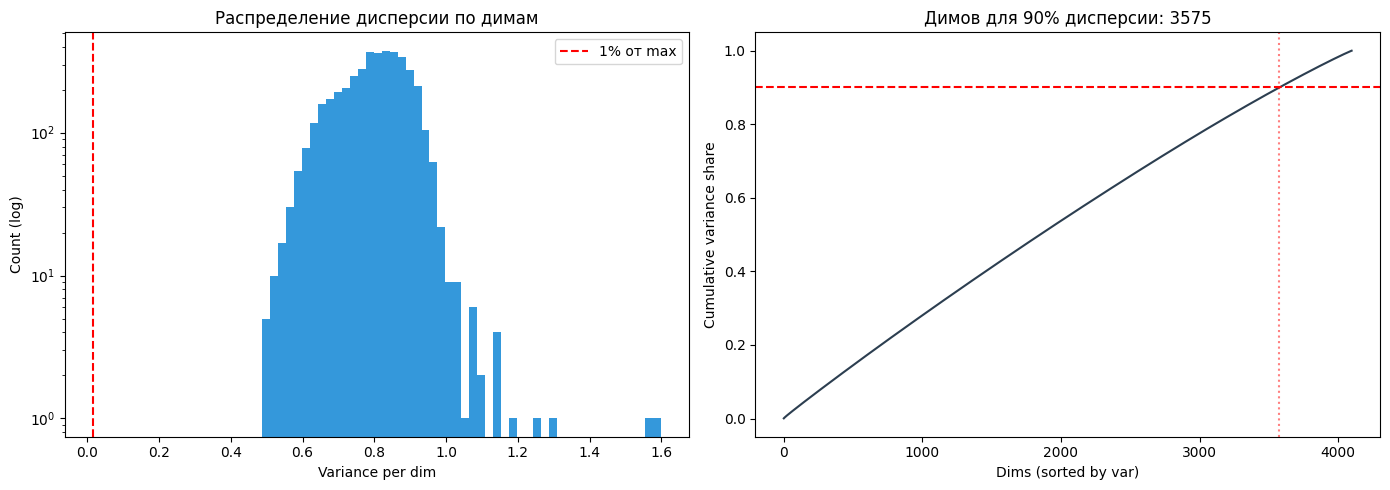

In [29]:
dim_var = Z.var(axis=0)  # (4096,)
max_var = dim_var.max()
alive_mask = dim_var > 0.01 * max_var
print(f"Dims total: {len(dim_var)}, max var: {max_var:.4f}")
print(f"Живые димы (>1% от max): {alive_mask.sum()} ({alive_mask.mean()*100:.1f}%)")
print(f"Мёртвые димы (<1% от max): {(~alive_mask).sum()}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(dim_var, bins=50, log=True, color="#3498db")
axes[0].axvline(0.01 * max_var, color="r", linestyle="--", label="1% от max")
axes[0].set_xlabel("Variance per dim")
axes[0].set_ylabel("Count (log)")
axes[0].set_title("Распределение дисперсии по димам")
axes[0].legend()

sorted_var = np.sort(dim_var)[::-1]
cum = np.cumsum(sorted_var) / sorted_var.sum()
n90 = int(np.searchsorted(cum, 0.9)) + 1
axes[1].plot(range(1, len(cum) + 1), cum, color="#2c3e50")
axes[1].axhline(0.9, color="r", linestyle="--")
axes[1].axvline(n90, color="r", linestyle=":", alpha=0.5)
axes[1].set_xlabel("Dims (sorted by var)")
axes[1].set_ylabel("Cumulative variance share")
axes[1].set_title(f"Димов для 90% дисперсии: {n90}")
plt.tight_layout()
plt.show()

### 7.5 Ближайшие соседи

Для случайных кадров — 3 ближайших соседа по латенту (евклидово расстояние).
**Главный тест осмысленности**: похожи ли соседи визуально?
Если да — латент структурирован и подходит для предиктора.
Если нет — соседи близки случайно (рыхлый латент).

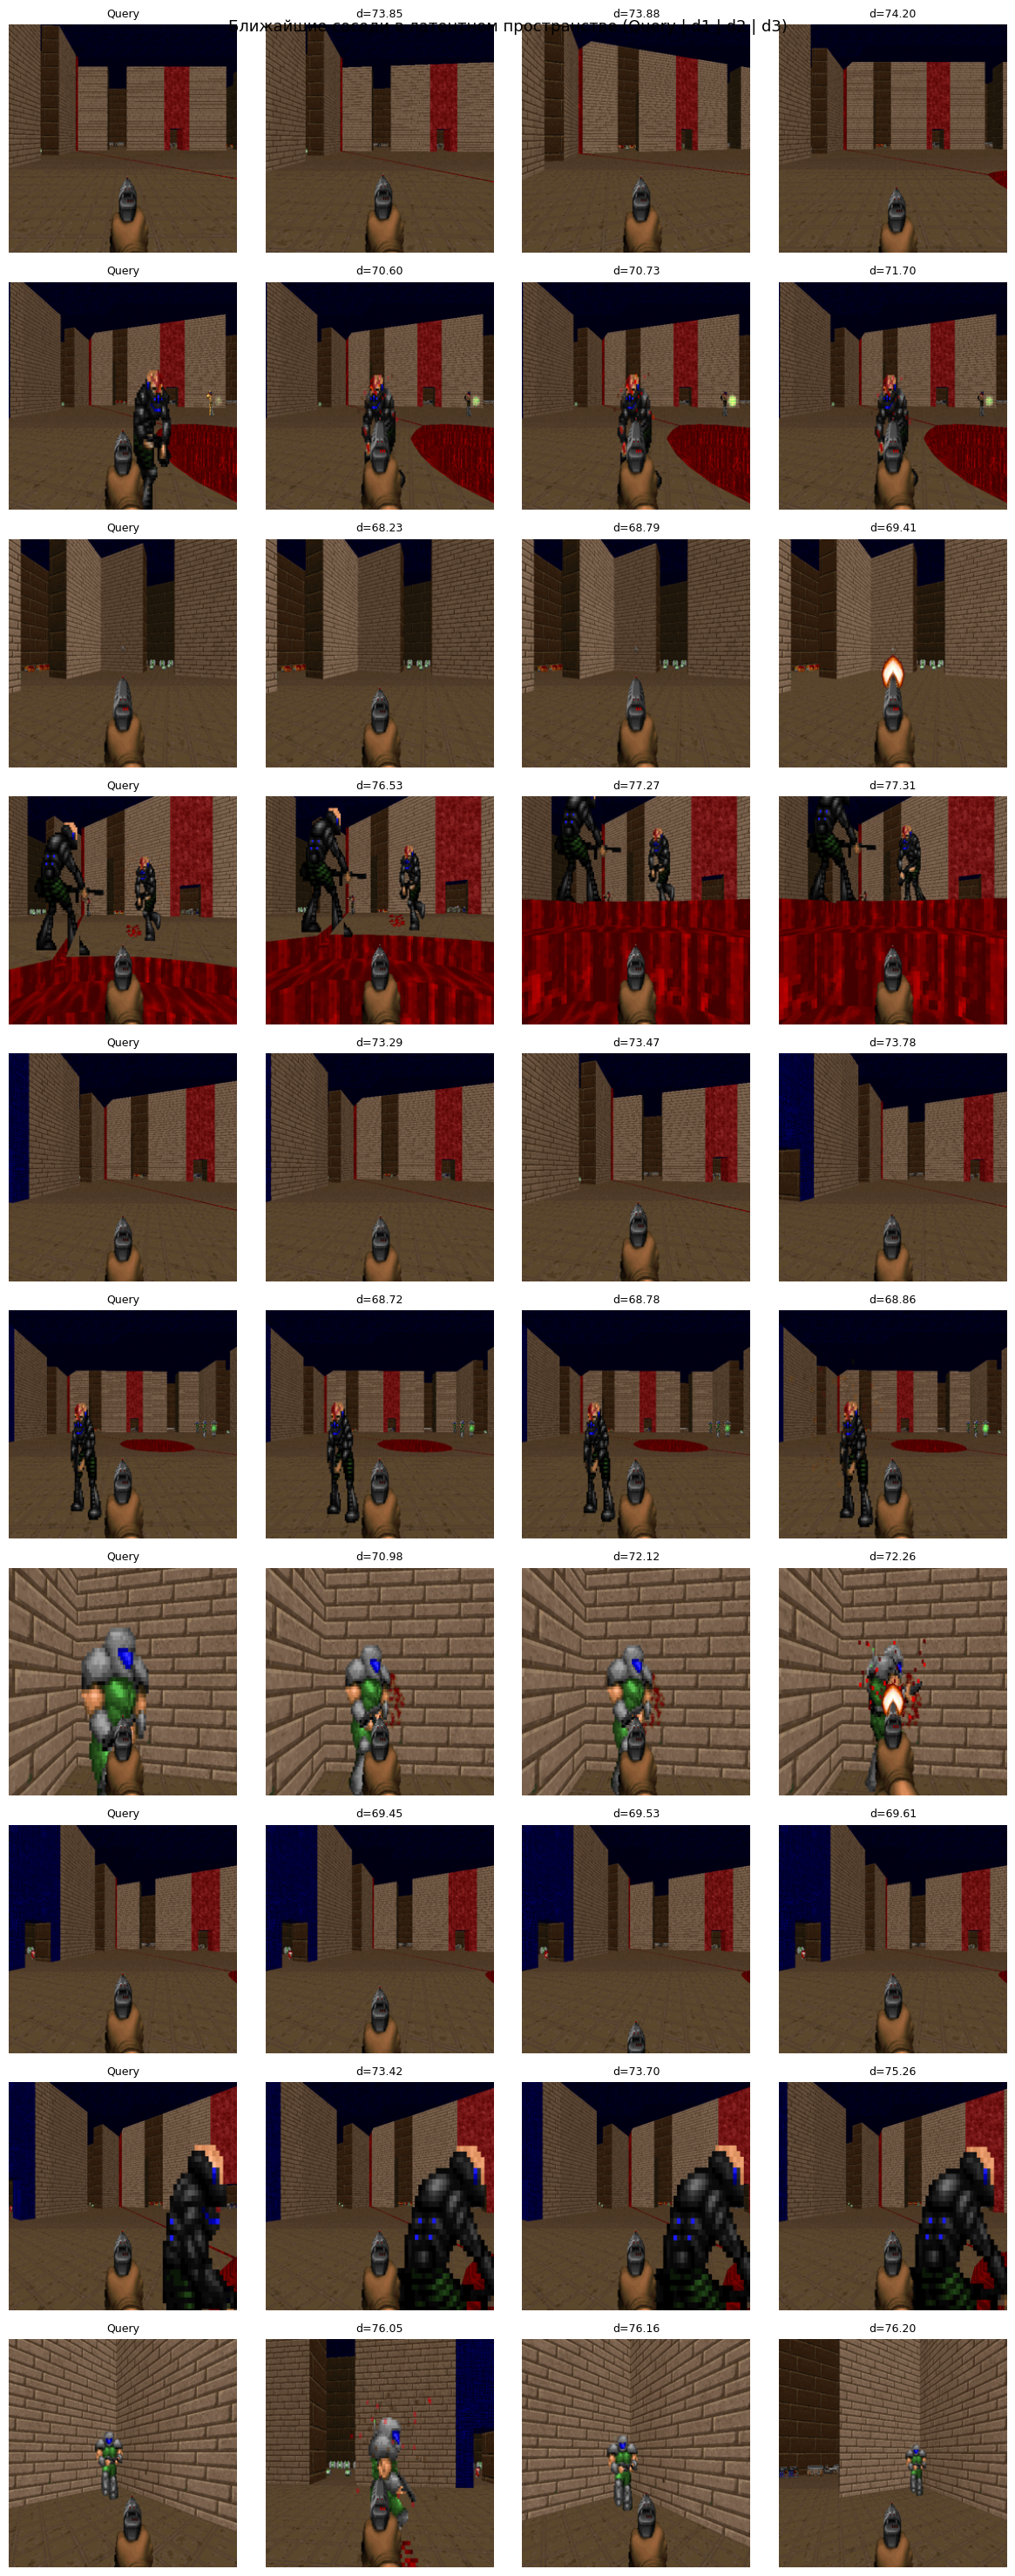

In [30]:
from sklearn.neighbors import NearestNeighbors

N_QUERIES = 10   # сколько случайных запросов
K_NEIGHBORS = 4  # сам запрос + 3 соседа

rng = np.random.default_rng(42)
query_idx = rng.choice(len(Z), size=N_QUERIES, replace=False)

nn = NearestNeighbors(n_neighbors=K_NEIGHBORS, metric="euclidean")
nn.fit(Z)
dists, neigh_idx = nn.kneighbors(Z[query_idx])

fig, axes = plt.subplots(N_QUERIES, K_NEIGHBORS, figsize=(3 * K_NEIGHBORS, 3 * N_QUERIES))
for r in range(N_QUERIES):
    for c in range(K_NEIGHBORS):
        ni = int(neigh_idx[r][c])
        img = dataset[int(frame_orig_idx[ni])].permute(1, 2, 0).numpy()
        axes[r, c].imshow(img)
        axes[r, c].axis("off")
        axes[r, c].set_title("Query" if c == 0 else f"d={dists[r][c]:.2f}", fontsize=9)
plt.suptitle("Ближайшие соседи в латентном пространстве (Query | d1 | d2 | d3)", fontsize=13)
plt.tight_layout()
plt.show()

### 7.6 Как интерпретировать

| Признак | Значение |
|---|---|
| **PC1+PC2 < 10%** | Нужно > 50 компонент → латент «рыхлый», избыточные димы. Сжать через обученную проекцию до 256–512 |
| **PC1+PC2 > 30%** | Латент хорошо структурирован, 2D проекция репрезентативна |
| **Ленты-траектории** | Временная связность → предиктор сможет моделировать динамику |
| **Облако шума** | Нет структуры — мало эпох/мало данных/латент слишком велик |
| **Дискретные кластеры** | Разные сцены (коридор/комната/бой) — хорошо, но нужны переходы |
| **N для 90% (PCA)** | Если > 100 — латент избыточен. Если < 20 — предиктору хватит 32-64 димов |
| **Живые димы (7.4)** | Если <20% димов живые — можно смело резать размерность. Если >80% — сжатие проекцией понесёт потери |
| **Соседи похожи (7.5)** | Латент осмысленный → предиктор будет работать. Соседи не похожи → латент рыхлый/переобученный |
